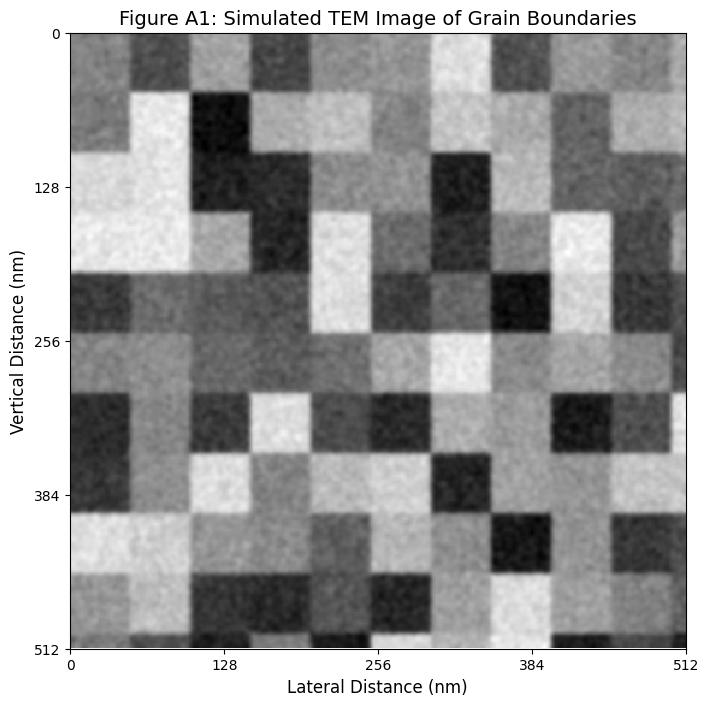

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Generate a synthetic polycrystalline thin film structure with grain boundaries
def generate_grain_structure(size, grain_size, noise_level=0.2):
    """Simulates a polycrystalline structure by generating random grain orientations."""
    num_grains = size // grain_size + 1  # Ensure full size coverage
    random_seeds = np.random.rand(num_grains, num_grains)

    # Upscale using repetition to form the grain structure
    grain_map = np.kron(random_seeds, np.ones((grain_size, grain_size)))

    # Trim to exact size
    grain_map = grain_map[:size, :size]

    # Generate noise array matching the grain_map shape
    noise = np.random.normal(scale=noise_level, size=grain_map.shape)

    # Add noise to simulate realistic TEM contrast
    grain_map += noise

    # Apply Gaussian smoothing to mimic diffraction contrast
    grain_map = gaussian_filter(grain_map, sigma=2)

    return grain_map

# Define simulation parameters
size = 512  # Image resolution
grain_size = 50  # Approximate grain size in pixels

# Generate simulated TEM grain boundary image
grain_boundaries = generate_grain_structure(size, grain_size)

# Create the figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grain_boundaries, cmap='gray', interpolation='nearest')

# Add X and Y axis labels
ax.set_xlabel("Lateral Distance (nm)", fontsize=12)
ax.set_ylabel("Vertical Distance (nm)", fontsize=12)

# Add axis ticks and grid
ax.set_xticks(np.linspace(0, size, 5))
ax.set_yticks(np.linspace(0, size, 5))
ax.grid(visible=False)  # No grid for a more TEM-like effect

# Add title
ax.set_title("Figure A1: Simulated TEM Image of Grain Boundaries", fontsize=14)

# Save the figure as a high-resolution PNG
fig.savefig("simulated_tem_grain_boundaries.png", dpi=300, bbox_inches='tight')

# Show the figure
plt.show()


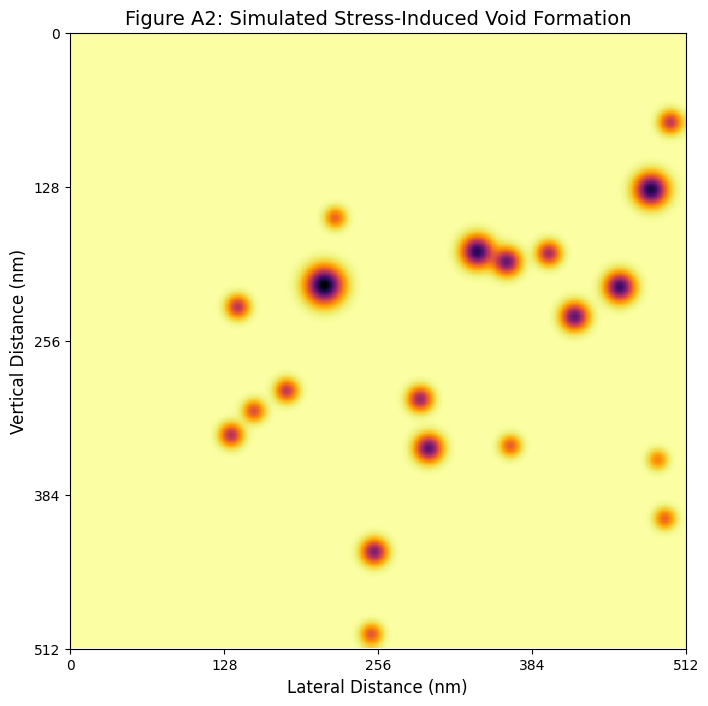

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Generate a synthetic stress-induced void formation map
def generate_void_structure(size, num_voids, void_size_range, stress_intensity=0.5):
    """Simulates stress-induced void formation in a thin-film structure."""
    void_map = np.zeros((size, size))

    # Randomly place voids of different sizes
    for _ in range(num_voids):
        x, y = np.random.randint(0, size, 2)
        void_size = np.random.randint(void_size_range[0], void_size_range[1])

        # Create circular voids using a Gaussian profile
        xv, yv = np.meshgrid(np.linspace(-1, 1, void_size), np.linspace(-1, 1, void_size))
        void = np.exp(-(xv**2 + yv**2) * 10)  # Higher exponent makes sharper void edges

        # Ensure void placement does not exceed image boundaries
        x_start, x_end = max(0, x - void_size//2), min(size, x + void_size//2)
        y_start, y_end = max(0, y - void_size//2), min(size, y + void_size//2)

        void_map[x_start:x_end, y_start:y_end] += void[:x_end-x_start, :y_end-y_start]

    # Apply Gaussian smoothing to simulate stress effects
    void_map = gaussian_filter(void_map, sigma=5)

    # Normalize and invert to create stress contrast
    void_map = 1 - (void_map / np.max(void_map)) * stress_intensity

    return void_map

# Define simulation parameters
size = 512  # Image resolution
num_voids = 20  # Number of voids
void_size_range = (20, 80)  # Range of void sizes in pixels

# Generate simulated stress-induced void formation
void_map = generate_void_structure(size, num_voids, void_size_range)

# Create the figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(void_map, cmap='inferno', interpolation='nearest')

# Add labels
ax.set_title("Figure A2: Simulated Stress-Induced Void Formation", fontsize=14)
ax.set_xlabel("Lateral Distance (nm)", fontsize=12)
ax.set_ylabel("Vertical Distance (nm)", fontsize=12)

# Add axis ticks and adjust scale
ax.set_xticks(np.linspace(0, size, 5))
ax.set_yticks(np.linspace(0, size, 5))

# Save the figure as high-resolution PNG
fig.savefig("simulated_stress_void_formation.png", dpi=300, bbox_inches='tight')

# Show the figure
plt.show()


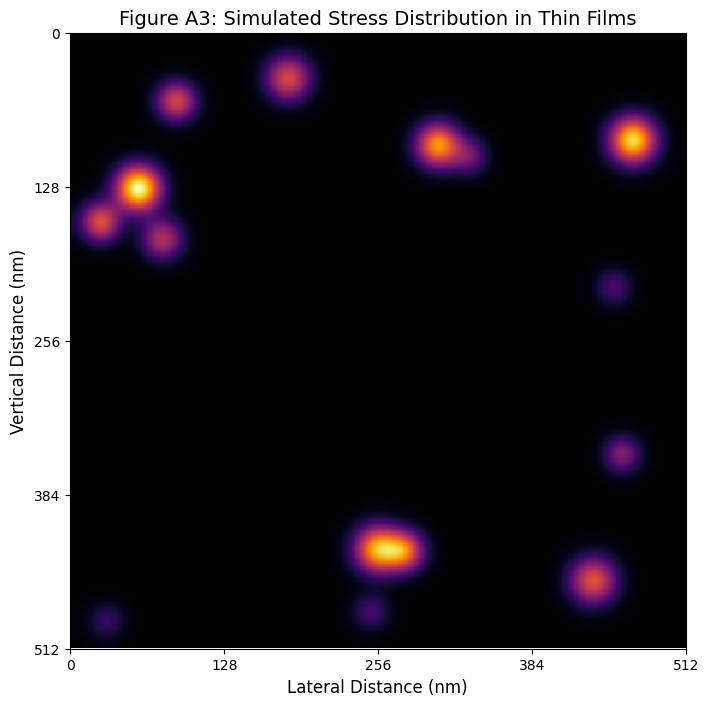

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Generate a synthetic stress distribution map in thin films
def generate_stress_distribution(size, num_stress_zones, stress_intensity_range):
    """Simulates stress distribution in a thin-film structure under thermal cycling."""
    stress_map = np.zeros((size, size))

    # Randomly generate stress concentration zones
    for _ in range(num_stress_zones):
        x, y = np.random.randint(0, size, 2)
        stress_intensity = np.random.uniform(*stress_intensity_range)
        zone_size = np.random.randint(30, 100)

        # Create stress zones using Gaussian profile
        xv, yv = np.meshgrid(np.linspace(-1, 1, zone_size), np.linspace(-1, 1, zone_size))
        stress_zone = stress_intensity * np.exp(-(xv**2 + yv**2) * 10)

        # Ensure stress zones fit within boundaries
        x_start, x_end = max(0, x - zone_size//2), min(size, x + zone_size//2)
        y_start, y_end = max(0, y - zone_size//2), min(size, y + zone_size//2)

        stress_map[x_start:x_end, y_start:y_end] += stress_zone[:x_end-x_start, :y_end-y_start]

    # Apply Gaussian smoothing to create realistic stress gradients
    stress_map = gaussian_filter(stress_map, sigma=10)

    # Normalize stress values
    stress_map /= np.max(stress_map)

    return stress_map

# Define simulation parameters
size = 512  # Image resolution
num_stress_zones = 15  # Number of stress concentration zones
stress_intensity_range = (0.5, 1.0)  # Range of stress intensity

# Generate simulated stress distribution
stress_map = generate_stress_distribution(size, num_stress_zones, stress_intensity_range)

# Create the figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(stress_map, cmap='inferno', interpolation='nearest')

# Add labels
ax.set_title("Figure A3: Simulated Stress Distribution in Thin Films", fontsize=14)
ax.set_xlabel("Lateral Distance (nm)", fontsize=12)
ax.set_ylabel("Vertical Distance (nm)", fontsize=12)

# Add axis ticks and adjust scale
ax.set_xticks(np.linspace(0, size, 5))
ax.set_yticks(np.linspace(0, size, 5))

# Save the figure as high-resolution PNG
fig.savefig("simulated_stress_distribution.png", dpi=300, bbox_inches='tight')

# Show the figure
plt.show()


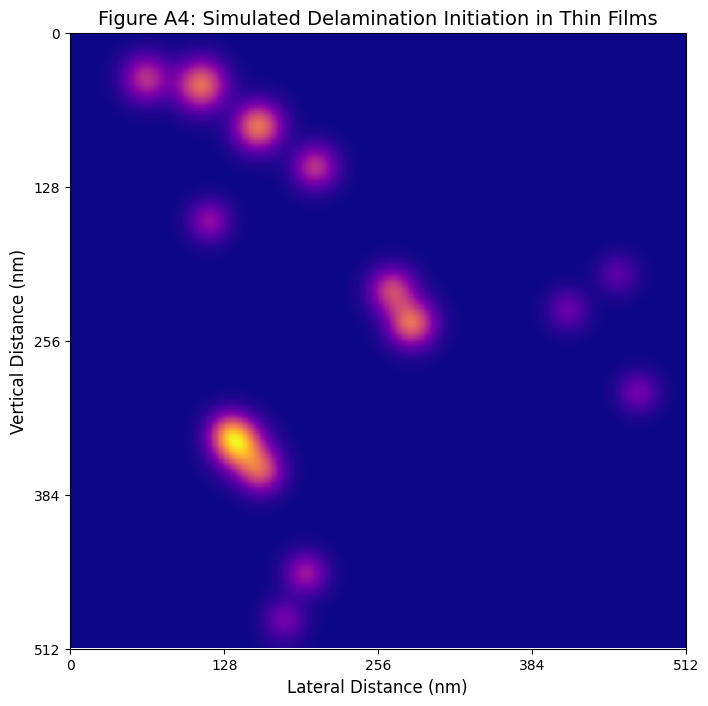

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Generate a synthetic delamination risk map in a multilayer thin film
def generate_delamination_map(size, num_delamination_zones, delamination_intensity_range):
    """Simulates delamination initiation points in a multilayer thin film using stress concentration mapping."""
    delam_map = np.zeros((size, size))

    # Randomly generate delamination-prone areas
    for _ in range(num_delamination_zones):
        x, y = np.random.randint(0, size, 2)
        delamination_intensity = np.random.uniform(*delamination_intensity_range)
        zone_size = np.random.randint(30, 100)

        # Create delamination zones using Gaussian profile
        xv, yv = np.meshgrid(np.linspace(-1, 1, zone_size), np.linspace(-1, 1, zone_size))
        delamination_zone = delamination_intensity * np.exp(-(xv**2 + yv**2) * 10)

        # Ensure delamination zones fit within boundaries
        x_start, x_end = max(0, x - zone_size//2), min(size, x + zone_size//2)
        y_start, y_end = max(0, y - zone_size//2), min(size, y + zone_size//2)

        delam_map[x_start:x_end, y_start:y_end] += delamination_zone[:x_end-x_start, :y_end-y_start]

    # Apply Gaussian smoothing to create realistic stress distribution
    delam_map = gaussian_filter(delam_map, sigma=10)

    # Normalize values for visualization
    delam_map /= np.max(delam_map)

    return delam_map

# Define simulation parameters
size = 512  # Image resolution
num_delamination_zones = 15  # Number of potential delamination points
delamination_intensity_range = (0.5, 1.0)  # Range of stress intensity

# Generate simulated delamination map
delam_map = generate_delamination_map(size, num_delamination_zones, delamination_intensity_range)

# Create the figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(delam_map, cmap='plasma', interpolation='nearest')

# Add labels
ax.set_title("Figure A4: Simulated Delamination Initiation in Thin Films", fontsize=14)
ax.set_xlabel("Lateral Distance (nm)", fontsize=12)
ax.set_ylabel("Vertical Distance (nm)", fontsize=12)

# Add axis ticks and adjust scale
ax.set_xticks(np.linspace(0, size, 5))
ax.set_yticks(np.linspace(0, size, 5))

# Save the figure as high-resolution PNG
fig.savefig("simulated_delamination_initiation.png", dpi=300, bbox_inches='tight')

# Show the figure
plt.show()
